Note: The group acknowledges that AI tools were used to refine the function syntax, specifically for tasks such as peak detection and labeling. All other parameter selections were made through trial-and-error and represent human judgment.

# Aim:
Determination of spin-orbit coupling constant of $𝟒_𝑭$ and $𝟒_𝑫$ states of
copper.

# Apparatus:
1. Copper rods
2. Graduated optical bench
3. XYZ translational mount
4. LED
5. Objective 20X
6. Optical fibre
7. Spectrometer
8. High voltage power supply
9. Sodium lamp

# Theory:

In atomic spectrum, to describe the fine structure, total energy of the atom can be expressed as $E = E_0 + ΔE$,
Where $ΔE$ represents the perturbation energy due to spin orbit coupling, and $E_0$ represents the unperturbed energy of the atomic state.

The perturbation energy due to spin orbit coupling
can be expressed as $ΔE = A(L, S)\vec{L}⋅\vec{S}$, where $A(L, S)$ is a constant depending on L, and S.

Meanwhile, $\vec{L}⋅\vec{S}$ is given by $\frac{J^2-L^2-S^2}{2}$, therefore $ΔE$ is given by $A(L,S)[J(J+1)–L(L+1)–S(S+1)]/2$



The possible transitions for copper are:
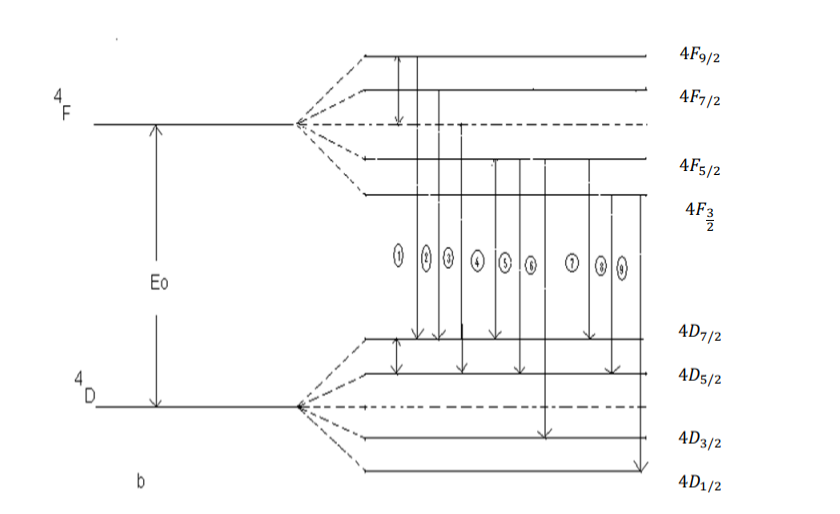

Possible transitions for sodium are:
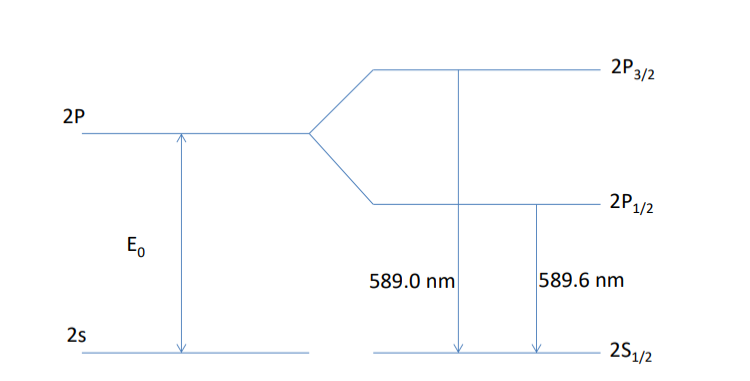

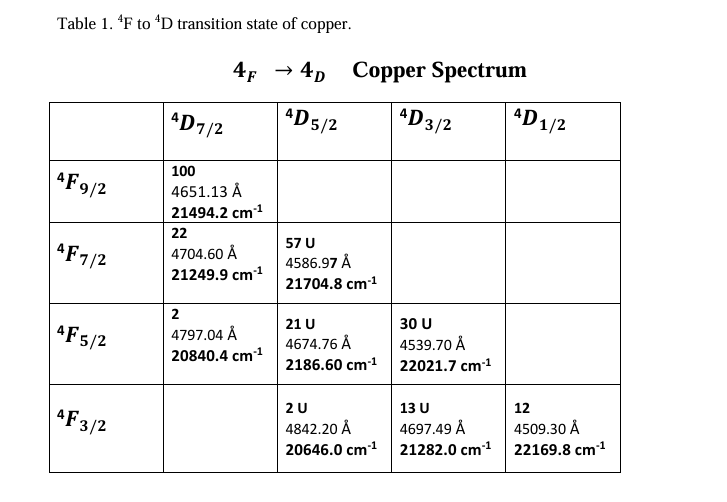

# Analysis:

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

In [ ]:
file = "g15 data.csv"
df = pd.read_csv(file)
wl = np.array(df.iloc[:, 0].values)   # wavelength
c1 = np.array(df.iloc[:, 1].values)   # LED
c2 = np.array(df.iloc[:, 2].values)   # Copper
c3 = np.array(df.iloc[:, 3].values)   # Sodium
print(df)

      Wavelength [nm]   led.RAW8  peaks.RAW8  sodium.RAW8
0             378.466  39.200001   85.400002        -18.0
1             378.544 -28.000000   85.400002          0.0
2             378.621   8.600000   57.400002         -8.8
3             378.699  -8.000000   60.400002        -12.4
4             378.777  37.599998   67.199997          1.6
...               ...        ...         ...          ...
3643          627.321 -31.799999    4.000000        -14.4
3644          627.378 -24.400000   33.599998          8.2
3645          627.435  -4.400000   31.200001          1.4
3646          627.493 -31.200001    6.600000         22.4
3647          627.550 -27.000000   19.400000          3.2

[3648 rows x 4 columns]


In [ ]:
# peak detection
peaks, props = find_peaks(c2,prominence=0.015*np.max(c2),distance=2)
peak_wl = wl[peaks]
peak_I  = c2[peaks]

# sorting
order = np.argsort(peak_wl)
peak_wl = peak_wl[order]
peak_I  = peak_I[order]

print("Cu peaks:")
for w in peak_wl:
  print(f"{w:.2f} nm")

Cu peaks:
406.23 nm
427.43 nm
465.05 nm
510.47 nm
515.28 nm
521.76 nm
529.20 nm
569.99 nm
578.13 nm


In [ ]:
labels = [
    r"$^4F_{3/2}\rightarrow ^4D_{1/2}$",
    r"$^4F_{5/2}\rightarrow ^4D_{3/2}$",
    r"$^4F_{7/2}\rightarrow ^4D_{5/2}$",
    r"$^4F_{9/2}\rightarrow ^4D_{7/2}$",
    r"$^4F_{5/2}\rightarrow ^4D_{5/2}$",
    r"$^4F_{3/2}\rightarrow ^4D_{3/2}$",
    r"$^4F_{7/2}\rightarrow ^4D_{7/2}$",
    r"$^4F_{5/2}\rightarrow ^4D_{7/2}$",
    r"$^4F_{3/2}\rightarrow ^4D_{5/2}$"
] # from manual

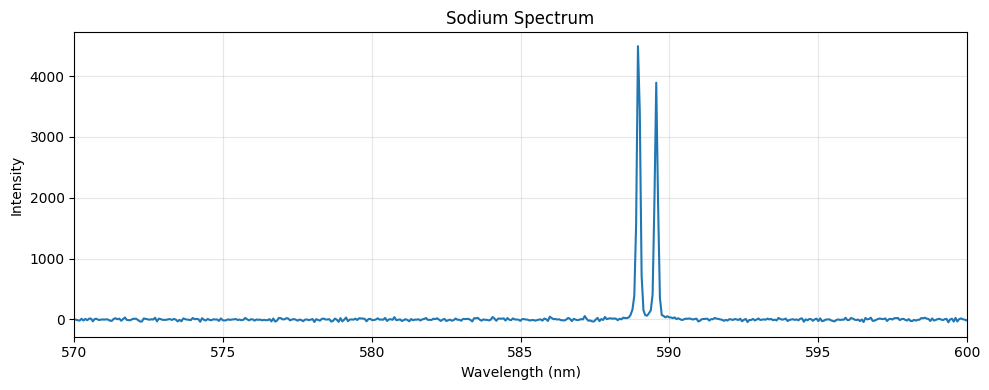

In [ ]:
# Sodium Plot
plt.figure(figsize=(10,4))
plt.plot(wl, c3)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")
plt.xlim(570,600)
plt.title("Sodium Spectrum")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

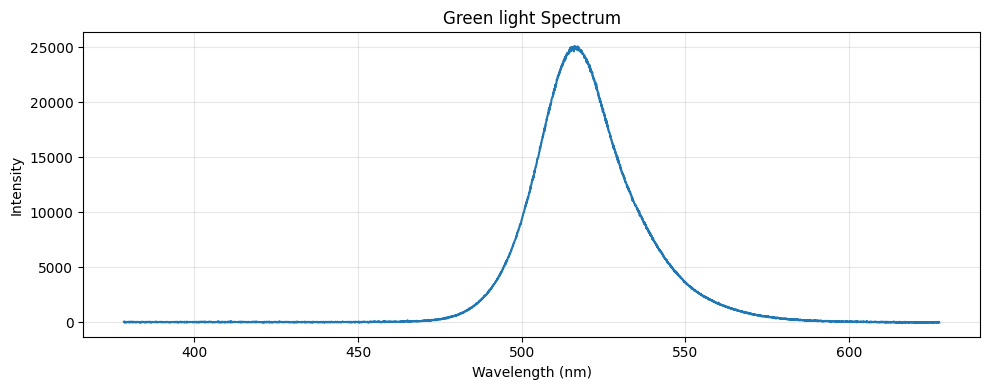

In [ ]:
# Green Laser Plot
plt.figure(figsize=(10,4))
plt.plot(wl, c1)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")
plt.title("Green light Spectrum")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

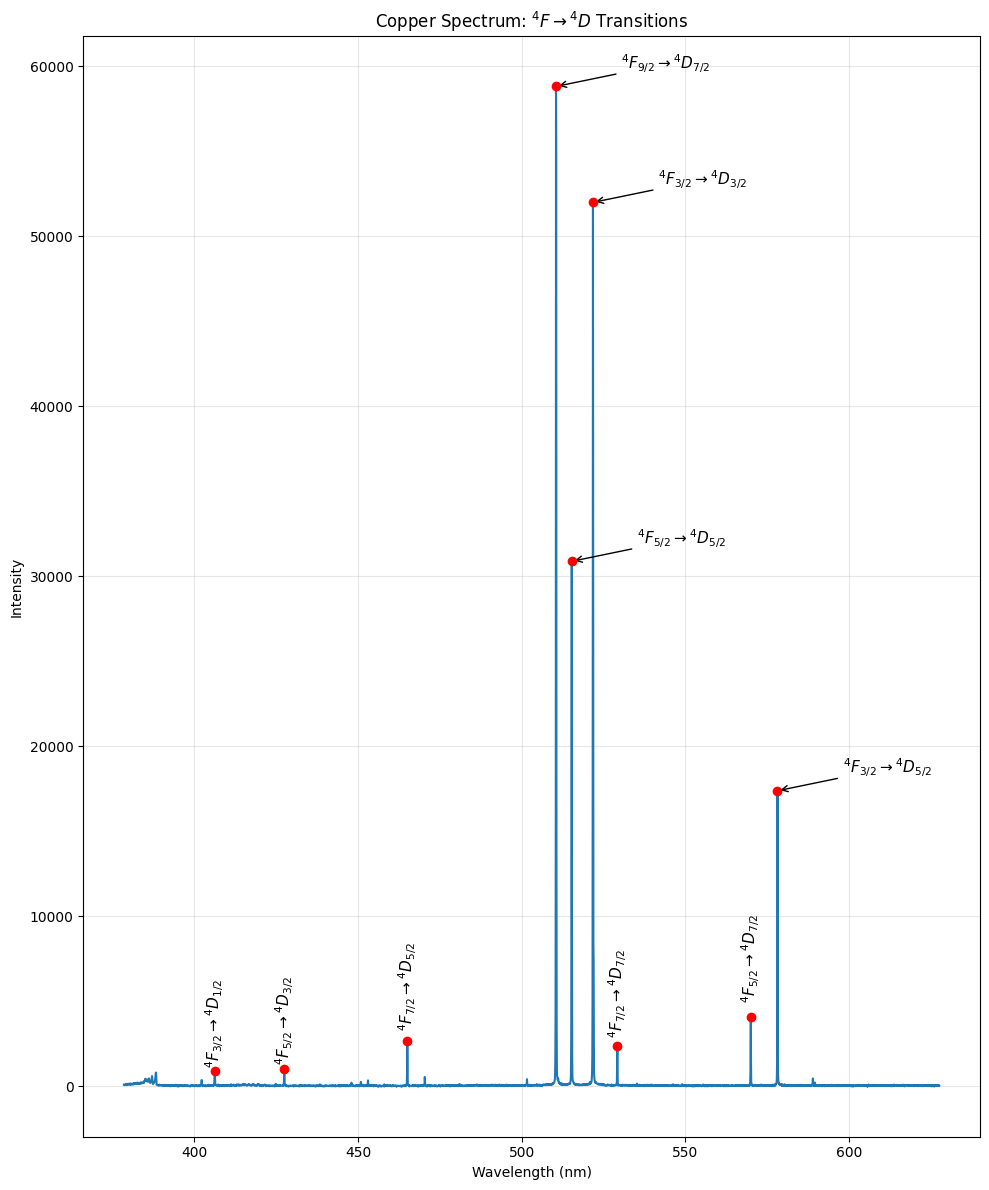

In [ ]:
# Cu Plot
plt.figure(figsize=(10,12))
plt.plot(wl, c2, lw=1.5)
plt.scatter(peak_wl, peak_I, color="red", zorder=5)

# indices of 4 highest peaks
top4_idx = np.argsort(peak_I)[-4:]

for i, (w, I, lab) in enumerate(zip(peak_wl, peak_I, labels)):
    if i in top4_idx:
        # Arrow annotation for tall peaks
        plt.annotate(
            lab,
            xy=(w, I),
            xytext=(w + 20, I + 1000),
            fontsize=11,
            ha="left",
            arrowprops=dict(arrowstyle="->", lw=1)
        )
    else:
        # Vertical text for smaller peaks
        plt.text(
            w, I*1.2, lab,
            rotation=90,
            ha="center",
            va="bottom",
            fontsize=11
        )
plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")
plt.title("Copper Spectrum: $^4F \\rightarrow ^4D$ Transitions")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Calculations:
$\Delta E$ for different orbitals -
- $4F_{9/2} = \frac{9A_1}{2}$
- $4F_{7/2} = 0$
- $4F_{5/2} = \frac{-7A_1}{2}$
- $4F_{3/2} = -6A_1$
- $4D_{7/2} = 3A_2$
- $4D_{5/2} = \frac{-A_2}{2}$
- $4F_{3/2} = -3A_2$
- $4F_{1/2} = \frac{-9A_2}{2}$

We consider three transitions -
* $4F_{7/2} \rightarrow 4D_{5/2}$, $\lambda = 465.05$
* $4F_{9/2} \rightarrow 4D_{7/2}$, $\lambda = 510.47$
* $4F_{7/2} \rightarrow 4D_{7/2}$, $\lambda = 529.20$

In [ ]:
lambda_A = np.array([465.05, 510.47, 529.20])

# Convert to wavenumber (cm^-1)
nu = 1e7 / lambda_A
nu1, nu2, nu3 = nu

"""
System of equations:
E0+(1/2)A2=nu1
E0+(9/2)A1-(3)A2=nu2
E0-3A2=nu3
"""
A = np.array([[1,0,1/2],[1,9/2,-3],[1,0,-3]])
b = np.array([nu1, nu2, nu3])

E0, A1, A2 = np.linalg.solve(A, b)
print(f"E0 = {E0:.2f} cm^-1")
print(f"A1 = {A1:.2f} cm^-1")
print(f"A2 = {A2:.2f} cm^-1")


E0 = 21130.69 cm^-1
A1 = 154.08 cm^-1
A2 = 744.75 cm^-1


# Results:
From the above analysis, we get -
- Coupling Constant for $4F=A_1 = 154.08 \, \text{cm}^{-1}$
- Coupling Constant for $4D=A_2 = 744.75 \, \text{cm}^{-1}$

And the transition energy: $E_0 = 21130.69 \, \text{cm}^{-1}$